In [1]:
import h5py
from h5glance import H5Glance
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import PolyCollection
import os

import xarray as xr
import cartopy.crs as ccrs

c:\Users\crist\miniconda3\envs\grib_env\Lib\site-packages\pyproj\network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)


In [2]:
FILE_PATH = r'C:\Users\crist\Documents\VU, Data Science\6 semestras\Duomenu mokslo projektas\GIT\GOME2B\2026\01\01\GOME_O3-NO2-NO2Tropo-BrO-SO2-H2O-HCHO_L2_20260101022739_051_METOPB_68952_DLR_04.HDF5'

https://www.hdfgroup.org/wp-content/uploads/2020/10/h5glance-talk.html

In [3]:
f = h5py.File(FILE_PATH, 'r')
f.keys()

<KeysViewHDF5 ['CLOUD_PROPERTIES', 'DETAILED_RESULTS', 'GEOLOCATION', 'META_DATA', 'TOTAL_COLUMNS']>

In [4]:
f['CLOUD_PROPERTIES']

<HDF5 group "/CLOUD_PROPERTIES" (13 members)>

In [5]:
f['CLOUD_PROPERTIES'].keys()

<KeysViewHDF5 ['CloudFraction', 'CloudFraction_Error', 'CloudMode', 'CloudOpticalThickness', 'CloudOpticalThickness_Error', 'CloudTopAlbedo', 'CloudTopAlbedo_Error', 'CloudTopHeight', 'CloudTopHeight_Error', 'CloudTopPressure', 'CloudTopPressure_Error', 'CloudType', 'PMDCloudFraction']>

In [6]:
H5Glance(f)

C:\Users\crist\Documents\VU, Data Science\6 semestras\Duomenu mokslo projektas\GIT\GOME2B\2026\01\01\GOME_O3-NO2-NO2Tropo-BrO-SO2-H2O-HCHO_L2_20260101022739_051_METOPB_68952_DLR_04.HDF5/
├CLOUD_PROPERTIES	(13 children)
├DETAILED_RESULTS	(28 children)
├GEOLOCATION	(44 children)
├META_DATA	(6 children) (49 attributes)
└TOTAL_COLUMNS	(14 children)

In [7]:
print(f['/META_DATA/MainSpecies'][:])
print(f['/META_DATA/SolarShifts'][:])

[b'O3' b'NO2' b'BrO' b'SO2' b'H2O' b'HCHO']
[-0.01951741 -0.00199487  0.01642719 -0.10205438 -0.00011763  0.00503153
  0.0139532 ]


In [8]:
print(f['/TOTAL_COLUMNS/BrO'][:])

[-1.0000000e+00  3.7847566e+13  4.0278728e+13 ...  1.7604832e+13
  2.8033082e+13  1.6380677e+13]


In [9]:
def save_h5_tree(obj, file, pre=''):
    items = len(obj)
    for i, (key, item) in enumerate(obj.items()):
        is_last = (i == items - 1)
        dash = '└── ' if is_last else '├── '
        
        if isinstance(item, h5py.Group):
            file.write(f"{pre}{dash}{key}/\n")
            save_h5_tree(item, file, pre + ('    ' if is_last else '│   '))
        else:
            file.write(f"{pre}{dash}{key} {item.shape} {item.dtype}\n")

OUTPUT_FILE = "hdf5_structure.txt"

with h5py.File(FILE_PATH, 'r') as f:
    with open(OUTPUT_FILE, 'w', encoding='utf-8') as txt_file:
        txt_file.write(f"Full Hierarchy of: {FILE_PATH}\n")
        txt_file.write("="*50 + "\n")
        save_h5_tree(f, txt_file)

print(f"The full tree has been saved to: {OUTPUT_FILE}")

The full tree has been saved to: hdf5_structure.txt


In [10]:
ds = xr.open_dataset(FILE_PATH, group='DETAILED_RESULTS', engine='h5netcdf')
geo = xr.open_dataset(FILE_PATH, group='GEOLOCATION', engine='h5netcdf')

C:\Users\crist\AppData\Local\Temp\ipykernel_4696\533706113.py:1: UserWarning: The 'phony_dims' kwarg now defaults to 'access'. Previously 'phony_dims=None' would raise an error. For full netcdf equivalence please use phony_dims='sort'.
  ds = xr.open_dataset(FILE_PATH, group='DETAILED_RESULTS', engine='h5netcdf')
C:\Users\crist\AppData\Local\Temp\ipykernel_4696\533706113.py:2: UserWarning: The 'phony_dims' kwarg now defaults to 'access'. Previously 'phony_dims=None' would raise an error. For full netcdf equivalence please use phony_dims='sort'.
  geo = xr.open_dataset(FILE_PATH, group='GEOLOCATION', engine='h5netcdf')


In [11]:
print(ds)

<xarray.Dataset> Size: 6MB
Dimensions:                         (phony_dim_0: 15020, phony_dim_1: 6)
Dimensions without coordinates: phony_dim_0, phony_dim_1
Data variables: (12/21)
    AAI                             (phony_dim_0) float32 60kB ...
    AMFToCloudTop                   (phony_dim_0, phony_dim_1) float32 360kB ...
    AMFToCloudTop_Error             (phony_dim_0, phony_dim_1) float32 360kB ...
    AMFToGround                     (phony_dim_0, phony_dim_1) float32 360kB ...
    AMFToGround_Error               (phony_dim_0, phony_dim_1) float32 360kB ...
    AMFTotal                        (phony_dim_0, phony_dim_1) float32 360kB ...
    ...                              ...
    SurfaceAlbedo                   (phony_dim_0, phony_dim_1) float32 360kB ...
    SurfaceConditionFlags           (phony_dim_0) int32 60kB ...
    SurfaceHeight                   (phony_dim_0) float32 60kB ...
    SurfacePressure                 (phony_dim_0) float32 60kB ...
    VCD                   

In [12]:
print(geo)

<xarray.Dataset> Size: 3MB
Dimensions:                          (phony_dim_0: 15020, phony_dim_1: 93880)
Dimensions without coordinates: phony_dim_0, phony_dim_1
Data variables: (12/44)
    EarthRadius                      (phony_dim_0) float32 60kB ...
    IndexInScan                      (phony_dim_0) int32 60kB ...
    InternalPixelId                  (phony_dim_0) int32 60kB ...
    LatitudeA                        (phony_dim_0) float32 60kB ...
    LatitudeB                        (phony_dim_0) float32 60kB ...
    LatitudeC                        (phony_dim_0) float32 60kB ...
    ...                               ...
    SubPixelInScan                   (phony_dim_0) int32 60kB ...
    SubSatellitePointLatitude        (phony_dim_0) float32 60kB ...
    SubSatellitePointLongitude       (phony_dim_0) float32 60kB ...
    SwathMode                        (phony_dim_0) int32 60kB ...
    Time                             (phony_dim_0) [('Day', '<i4'), ('MillisecondOfDay', '<i4')] 120

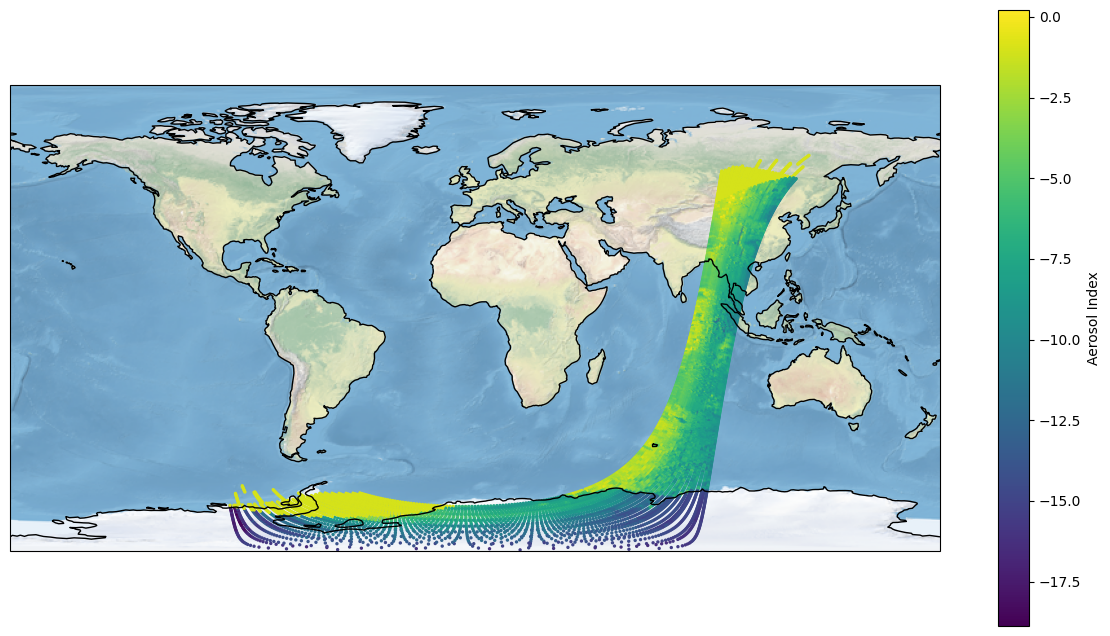

In [13]:
ds = ds.assign_coords({
    "lat": ("phony_dim_0", geo['LatitudeCentre'].values),
    "lon": ("phony_dim_0", geo['LongitudeCentre'].values)
})

plt.figure(figsize=(15, 8))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.stock_img()
ax.coastlines()

variable_to_plot = ds['AAI'] 

sc = plt.scatter(ds.lon, ds.lat, c=variable_to_plot, 
                 s=2, cmap='viridis', transform=ccrs.PlateCarree())

plt.colorbar(sc, label='Aerosol Index')
plt.show()

Loaded: GOME_O3-NO2-NO2Tropo-BrO-SO2-H2O-HCHO_L2_20260101004621_051_METOPB_68951_DLR_04.HDF5
Loaded: GOME_O3-NO2-NO2Tropo-BrO-SO2-H2O-HCHO_L2_20260101022739_051_METOPB_68952_DLR_04.HDF5
Loaded: GOME_O3-NO2-NO2Tropo-BrO-SO2-H2O-HCHO_L2_20260101040903_051_METOPB_68953_DLR_04.HDF5
Loaded: GOME_O3-NO2-NO2Tropo-BrO-SO2-H2O-HCHO_L2_20260101055027_051_METOPB_68954_DLR_04.HDF5
Loaded: GOME_O3-NO2-NO2Tropo-BrO-SO2-H2O-HCHO_L2_20260101073145_051_METOPB_68955_DLR_04.HDF5
Loaded: GOME_O3-NO2-NO2Tropo-BrO-SO2-H2O-HCHO_L2_20260101091309_051_METOPB_68956_DLR_04.HDF5
Loaded: GOME_O3-NO2-NO2Tropo-BrO-SO2-H2O-HCHO_L2_20260101105433_051_METOPB_68957_DLR_04.HDF5
Loaded: GOME_O3-NO2-NO2Tropo-BrO-SO2-H2O-HCHO_L2_20260101123827_049_METOPB_68958_DLR_04.HDF5
Loaded: GOME_O3-NO2-NO2Tropo-BrO-SO2-H2O-HCHO_L2_20260101141715_051_METOPB_68959_DLR_04.HDF5
Loaded: GOME_O3-NO2-NO2Tropo-BrO-SO2-H2O-HCHO_L2_20260101155839_051_METOPB_68960_DLR_04.HDF5
Loaded: GOME_O3-NO2-NO2Tropo-BrO-SO2-H2O-HCHO_L2_20260101173957_051_ME

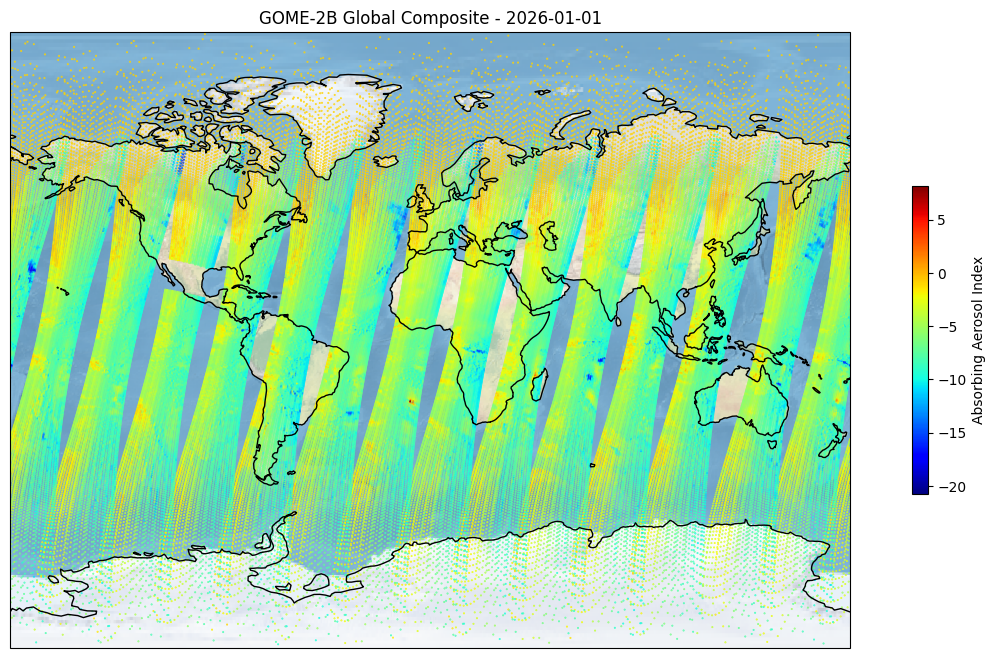

In [38]:
folder_path = r"C:\Users\crist\Documents\VU, Data Science\6 semestras\Duomenu mokslo projektas\GIT\GOME2B\2026\01\01"
all_lats = []
all_lons = []
all_values = []

for filename in os.listdir(folder_path):
    if filename.endswith(".h5") or filename.endswith(".HDF5"):
        file_path = os.path.join(folder_path, filename)
        
        try:
            with h5py.File(file_path, 'r') as f:
                geo = f['GEOLOCATION']
                lats = geo['LatitudeCentre'][:]
                lons = geo['LongitudeCentre'][:]
                
                data = f['DETAILED_RESULTS']['AAI'][:]
                
                if data.ndim > 1:
                    data = data[:, 0]
                
                all_lats.extend(lats)
                all_lons.extend(lons)
                all_values.extend(data)
                print(f"Loaded: {filename}")
        except Exception as e:
            print(f"Skipped {filename} due to error: {e}")

plt.figure(figsize=(16, 8))
ax = plt.axes(projection=ccrs.Miller())
ax.stock_img() 
ax.coastlines()

# Plot all points at once
sc = plt.scatter(all_lons, all_lats, c=all_values, s=.2, 
                 cmap='jet', transform=ccrs.LambertCylindrical())

plt.colorbar(sc, label='Absorbing Aerosol Index', shrink=0.5)
plt.title("GOME-2B Global Composite - 2026-01-01")
plt.show()

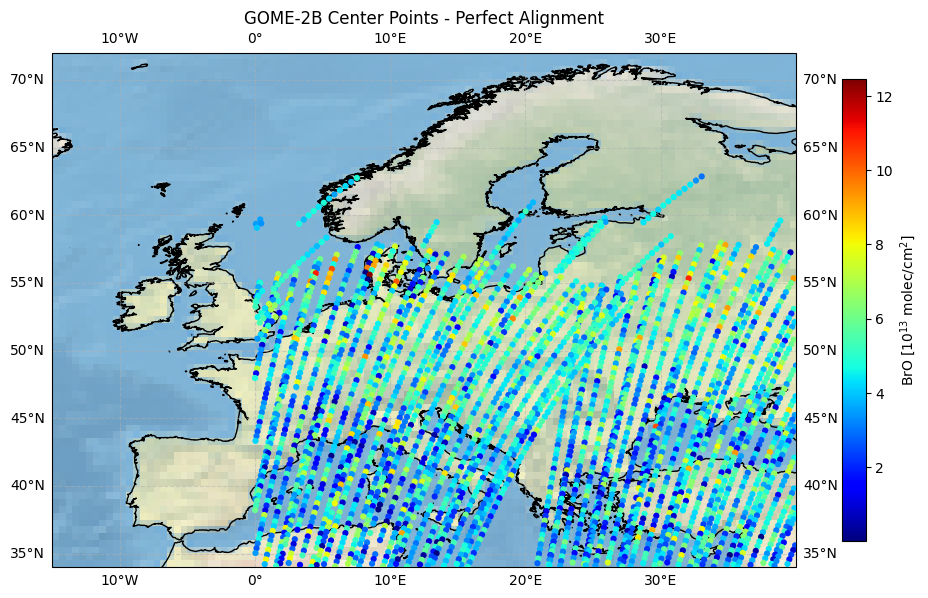

In [48]:
folder_path = r"C:\Users\crist\Documents\VU, Data Science\6 semestras\Duomenu mokslo projektas\GIT\GOME2B\2026\01\02"
EU_EXTENT = [-15, 40, 34, 72] 

# Use PlateCarree for both to ensure 1:1 alignment of degrees
map_proj = ccrs.PlateCarree()
data_proj = ccrs.PlateCarree()

all_lats = []
all_lons = []
all_vals = []

# --- 2. DATA LOADING ---
for filename in os.listdir(folder_path):
    if filename.upper().endswith(".HDF5"):
        try:
            with h5py.File(os.path.join(folder_path, filename), 'r') as f:
                geo = f['GEOLOCATION']
                det = f['TOTAL_COLUMNS']
                
                lats = geo['LatitudeCentre'][:]
                lons = geo['LongitudeCentre'][:]
                # Raw values (e.g. 3.7e13)
                data = det['BrO'][:, 0] if det['BrO'].ndim > 1 else det['BrO'][:]

                # Filter: Remove -1.0 flags and stay within Europe
                mask = (data > 0) & \
                       (lats >= EU_EXTENT[2]) & (lats <= EU_EXTENT[3]) & \
                       (lons >= EU_EXTENT[0]) & (lons <= EU_EXTENT[1])
                
                if np.any(mask):
                    all_lats.extend(lats[mask])
                    all_lons.extend(lons[mask])
                    # Divide by 1e13 for better visual contrast on the colorbar
                    all_vals.extend(data[mask] / 1e13)
                    
        except Exception as e:
            print(f"Error in {filename}: {e}")

# --- 3. VISUALIZATION ---
if not all_vals:
    print("No valid points found.")
else:
    all_lats = np.array(all_lats)
    all_lons = np.array(all_lons)
    all_vals = np.array(all_vals)

    fig = plt.figure(figsize=(12, 10))
    ax = plt.axes(projection=map_proj) # Now defined
    
    # Set the zoom window
    ax.set_extent(EU_EXTENT, crs=data_proj)
    
    # Map layers
    ax.stock_img()
    ax.coastlines(resolution='10m', color='black', linewidth=1)
    ax.gridlines(draw_labels=True, linestyle='--', alpha=0.5)

    # Plot the points
    # transform=data_proj tells Cartopy these are Lat/Lon degrees
    sc = ax.scatter(all_lons, all_lats, 
                    c=all_vals, 
                    s=20, 
                    cmap='jet', 
                    transform=data_proj, 
                    edgecolors='none',
                    zorder=3)

    plt.colorbar(sc, label=r'BrO [$10^{13}$ molec/cm$^2$]', shrink=0.6)
    plt.title("GOME-2B Center Points - Perfect Alignment")
    plt.show()